# Description

In this notebook, I will load the Llama3-2 weight and try quantize it

In [1]:
import os
import sys
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
torch.manual_seed(123)

from utils.model import Llama3Model, generate, text_to_token_ids, token_ids_to_text
from utils.tokenizer import Llama3Tokenizer, ChatFormat, clean_text
from utils.model import LLAMA32_CONFIG_1B, LLAMA32_CONFIG_3B

# 1. Load model

In [2]:
# ===== Hyper-parameter =====
MODEL_FILE = "/home/tnguyen10/Desktop/llm/model/llama3.2-1B-instruct.pth"
MODEL_CONTEXT_LENGTH = 8192  # Support up to 131_072
MAX_NEW_TOKENS = 2048
TEMPERATURE = 0.0
TOP_K = 1
TOKENIZER_FILE = "/home/tnguyen10/Desktop/llm/model/tokenizer.model"

device = "cuda"

In [3]:
# 1. Load model
if os.path.exists(MODEL_FILE) == False:
    print(f"[ERROR] Model does not exist !!!")
    sys.exit(0)

if "1B" in MODEL_FILE:
    llama32_config = LLAMA32_CONFIG_1B
elif "3B" in MODEL_FILE:
    llama32_config = LLAMA32_CONFIG_3B
else:
    print(f"[ERROR] Check model file again !!!")
    sys.exit(0)

llama32_config["context_length"] = MODEL_CONTEXT_LENGTH

model = Llama3Model(llama32_config)
checkpoint = torch.load(MODEL_FILE, weights_only=True, map_location=device)
model.load_state_dict(checkpoint)
model.to(device)

print(f"Model {MODEL_FILE} loaded successfully !!!")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params/1e6:.2f} M")

Model /home/tnguyen10/Desktop/llm/model/llama3.2-1B-instruct.pth loaded successfully !!!
Total parameters: 1498.48 M


In [4]:
# 2. Load tokenizer
if not os.path.exists(TOKENIZER_FILE):
    print(f"[ERROR] Does not have TOKENIZER_FILE")
    sys.exit(0)

tokenizer = Llama3Tokenizer(TOKENIZER_FILE)

if "instruct" in MODEL_FILE:
    tokenizer = ChatFormat(tokenizer)
print(f"Tokenizer loaded successfully.")

Tokenizer loaded successfully.


In [5]:
input_prompt = "What is the capital of Viet Nam?"
print(f"Input prompt: {input_prompt}")
print('-' * 80)

# 3. Generate text
start = time.time()

token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_prompt, tokenizer).to(device),
    max_new_tokens=MAX_NEW_TOKENS,
    context_size=llama32_config["context_length"],
    top_k=TOP_K,
    temperature=TEMPERATURE,
)

print(f"Generation time: {time.time() - start:.2f} sec")

output_text = token_ids_to_text(token_ids, tokenizer)
output_text = clean_text(output_text)
print("\nOutput text:\n", output_text)

Input prompt: What is the capital of Viet Nam?
--------------------------------------------------------------------------------

 [WARNING]: Reached limit of 2048 token without generating an EOS token. 

Generation time: 118.41 sec

Output text:
 The capital of Vietnam is Hanoi.


# 2. Inspect weight 

In [6]:
# print list layer of model
for name, param in model.named_parameters():
    print(f"{name}: {param.size()}")

tok_emb.weight: torch.Size([128256, 2048])
trf_blocks.0.att.W_key.weight: torch.Size([512, 2048])
trf_blocks.0.att.W_value.weight: torch.Size([512, 2048])
trf_blocks.0.att.W_query.weight: torch.Size([2048, 2048])
trf_blocks.0.att.out_proj.weight: torch.Size([2048, 2048])
trf_blocks.0.ff.fc1.weight: torch.Size([8192, 2048])
trf_blocks.0.ff.fc2.weight: torch.Size([8192, 2048])
trf_blocks.0.ff.fc3.weight: torch.Size([2048, 8192])
trf_blocks.0.norm1.weight: torch.Size([2048])
trf_blocks.0.norm2.weight: torch.Size([2048])
trf_blocks.1.att.W_key.weight: torch.Size([512, 2048])
trf_blocks.1.att.W_value.weight: torch.Size([512, 2048])
trf_blocks.1.att.W_query.weight: torch.Size([2048, 2048])
trf_blocks.1.att.out_proj.weight: torch.Size([2048, 2048])
trf_blocks.1.ff.fc1.weight: torch.Size([8192, 2048])
trf_blocks.1.ff.fc2.weight: torch.Size([8192, 2048])
trf_blocks.1.ff.fc3.weight: torch.Size([2048, 8192])
trf_blocks.1.norm1.weight: torch.Size([2048])
trf_blocks.1.norm2.weight: torch.Size([2048

We will inspect the first attention block

In [7]:
# Get weight of attention block
idx_block = 0

W_query = model.trf_blocks[idx_block].att.W_query.weight.data
W_key = model.trf_blocks[idx_block].att.W_key.weight.data
W_value = model.trf_blocks[idx_block].att.W_value.weight.data
W_out = model.trf_blocks[idx_block].att.out_proj.weight.data
W_fc1 = model.trf_blocks[idx_block].ff.fc1.weight.data
W_fc2 = model.trf_blocks[idx_block].ff.fc2.weight.data
W_fc3 = model.trf_blocks[idx_block].ff.fc3.weight.data

print(f"Shape of W_query: {W_query.shape}")
print(f"Shape of W_key: {W_key.shape}")
print(f"Shape of W_value: {W_value.shape}")
print(f"Shape of W_out: {W_out.shape}")
print(f"Shape of W_fc1: {W_fc1.shape}")
print(f"Shape of W_fc2: {W_fc2.shape}")
print(f"Shape of W_fc3: {W_fc3.shape}")

Shape of W_query: torch.Size([2048, 2048])
Shape of W_key: torch.Size([512, 2048])
Shape of W_value: torch.Size([512, 2048])
Shape of W_out: torch.Size([2048, 2048])
Shape of W_fc1: torch.Size([8192, 2048])
Shape of W_fc2: torch.Size([8192, 2048])
Shape of W_fc3: torch.Size([2048, 8192])


## 2.1. Quantize weight

Weight will be quantized in column

In [8]:
def quantized_column_matrix_int_symmetric(mat:torch.Tensor):
    """
    Symmetric quantization to int8 on a per-column basis.
    mat: input float tensor (e.g., torch.float32 or torch.bfloat16)
    """
    N, M = mat.shape
    qmin = -128
    qmax = 127
    
    max_vals, _ = torch.max(torch.abs(mat), dim=0, keepdim=True)  # shape (1, M)
    scales = (max_vals / qmax).squeeze(0)  # shape (M,)
    
    q_mat = torch.clamp(torch.round(mat / scales.unsqueeze(0)), qmin, qmax).to(torch.int8)  # shape (N, M)
    
    scales = scales.clone().detach().to(torch.float32)
    return q_mat, scales

In [9]:
W_query_q, W_query_list_scales = quantized_column_matrix_int_symmetric(W_query)
print(f"Shape of quantized W_query: {W_query_q.shape}")
print(f"Shape of W_query scales: {W_query_list_scales.shape}")

W_key_q, W_key_list_scales = quantized_column_matrix_int_symmetric(W_key)
print(f"Shape of quantized W_key: {W_key_q.shape}")
print(f"Shape of W_key scales: {W_key_list_scales.shape}")

W_value_q, W_value_list_scales = quantized_column_matrix_int_symmetric(W_value)
print(f"Shape of quantized W_value: {W_value_q.shape}")
print(f"Shape of W_value scales: {W_value_list_scales.shape}")

W_out_q, W_out_list_scales = quantized_column_matrix_int_symmetric(W_out)
print(f"Shape of quantized W_out: {W_out_q.shape}")
print(f"Shape of W_out scales: {W_out_list_scales.shape}")

Shape of quantized W_query: torch.Size([2048, 2048])
Shape of W_query scales: torch.Size([2048])
Shape of quantized W_key: torch.Size([512, 2048])
Shape of W_key scales: torch.Size([2048])
Shape of quantized W_value: torch.Size([512, 2048])
Shape of W_value scales: torch.Size([2048])
Shape of quantized W_out: torch.Size([2048, 2048])
Shape of W_out scales: torch.Size([2048])


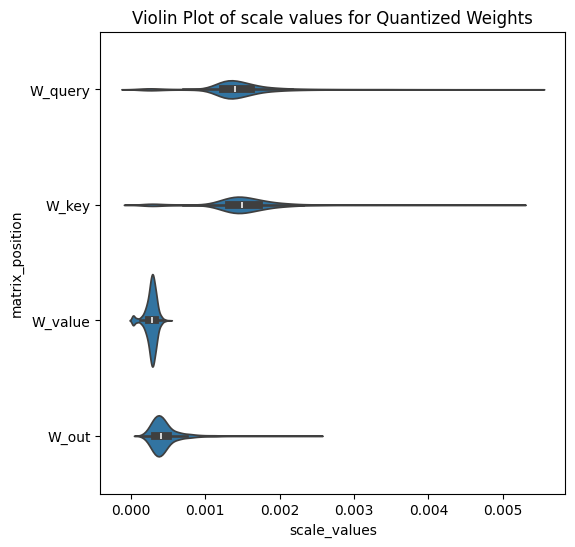

In [10]:
visualize_data = {
    'matrix_position': ['W_query'] * len(W_query_list_scales) + 
           ['W_key'] * len(W_key_list_scales) + 
           ['W_value'] * len(W_value_list_scales) + 
           ['W_out'] * len(W_out_list_scales),
    'scale_values': torch.cat([W_query_list_scales, W_key_list_scales, W_value_list_scales, W_out_list_scales]).cpu().numpy()
}

df = pd.DataFrame(visualize_data)

plt.figure(figsize=(6, 6))
sns.violinplot(x='scale_values', y='matrix_position', data=df)
plt.title('Violin Plot of scale values for Quantized Weights')
plt.show()

**COMMENT**: the scale value usually around similar value

We quantize the whole matrix

In [11]:
def quantize_matrix_symmetric_int8(mat:torch.Tensor):
    """
    Symmetric quantization to int8.
    mat: input float matrix (e.g., torch.float32 or torch.bfloat16)
    """
    max_val = torch.max(torch.abs(mat))
    
    qmin = -128
    qmax = 127
    scale = max_val / qmax
    
    q_mat = torch.clamp(torch.round(mat / scale), qmin, qmax).to(torch.int8)
    
    scale = scale.clone().detach().to(torch.float32)
    return q_mat, scale

In [12]:
W_query_q, W_query_global_scale = quantize_matrix_symmetric_int8(W_query)
print(f"Shape of scale: {W_query_global_scale.shape}")

W_key_q, W_key_global_scale = quantize_matrix_symmetric_int8(W_key)
print(f"Shape of scale: {W_key_global_scale.shape}")

W_value_q, W_value_global_scale = quantize_matrix_symmetric_int8(W_value)
print(f"Shape of scale: {W_value_global_scale.shape}")

W_out_q, W_out_global_scale = quantize_matrix_symmetric_int8(W_out)
print(f"Shape of scale: {W_out_global_scale.shape}")

Shape of scale: torch.Size([])
Shape of scale: torch.Size([])
Shape of scale: torch.Size([])
Shape of scale: torch.Size([])


## 2.2. Check quantization error

In [13]:
def de_quantize_column_matrix_int8_symmetric(q_mat:torch.Tensor, scale:torch.Tensor, out_dtype=torch.float16):
    """
    Dequantize int8 matrix to float on a per-column basis.
    q_mat: input int8 tensor (shape (N, M))
    scales: scale factors for each column (shape (N,))
    """
    output = q_mat.to(torch.float32) 
    output = output * scale[None, :]
    output = output.to(out_dtype)
    return output

def de_quantize_matrix_int8_symmetric(q_mat:torch.Tensor, scale:torch.Tensor, out_dtype=torch.float16):
    """
    Dequantize int8 matrix to float.
    q_mat: input int8 tensor (shape (N, M))
    scale: scale factor (scalar)
    """
    output = q_mat.to(torch.float32) 
    output = output * scale
    output = output.to(out_dtype)
    return output

def quantization_error_mse(original, dequantized):
    """
    Compute the Mean Squared Error (MSE) between the original and dequantized tensors.
    """
    return torch.mean((original - dequantized) ** 2)


def quantization_error_kl_divergence(original, dequantized, num_bins=2048, epsilon=1e-10):
    """
    Compute the KL divergence between the distributions of the original and dequantized tensors with float16.
    """
    orig_hist = torch.histc(original.float(), bins=num_bins, min=-1.0, max=1.0)
    deq_hist = torch.histc(dequantized.float(), bins=num_bins, min=-1.0, max=1.0)

    orig_prob = orig_hist / (torch.sum(orig_hist) + epsilon)
    deq_prob = deq_hist / (torch.sum(deq_hist) + epsilon)

    kl_div = torch.sum(orig_prob * torch.log((orig_prob + epsilon) / (deq_prob + epsilon)))
    return kl_div

In [14]:
for (weight, name) in [(W_query, "W_query"), (W_key, "W_key"), (W_value, "W_value"), (W_out, "W_out")]:
    # Column-wise quantization
    q_mat_col, scales_col = quantized_column_matrix_int_symmetric(weight)
    deq_mat_col = de_quantize_column_matrix_int8_symmetric(q_mat_col, scales_col)
    column_quant_error_mse = quantization_error_mse(weight, deq_mat_col)
    print(f"Column-wise Quantization Error (MSE) for {name}: {column_quant_error_mse.item():.6f}")

    # Global quantization
    q_mat_global, scale_global = quantize_matrix_symmetric_int8(weight)
    deq_mat_global = de_quantize_matrix_int8_symmetric(q_mat_global, scale_global)
    quant_global_error_mse = quantization_error_mse(weight, deq_mat_global)
    print(f"Global Quantization Error (MSE) for {name}: {quant_global_error_mse.item():.6f}")
    
    delta_quantity_error_mse = abs(column_quant_error_mse - quant_global_error_mse)
    print(f"Delta Quantization Error (MSE) for {name}: {delta_quantity_error_mse.item():.6f}")

    print('-' * 60)

Column-wise Quantization Error (MSE) for W_query: 0.000000
Global Quantization Error (MSE) for W_query: 0.000002
Delta Quantization Error (MSE) for W_query: 0.000002
------------------------------------------------------------
Column-wise Quantization Error (MSE) for W_key: 0.000000
Global Quantization Error (MSE) for W_key: 0.000002
Delta Quantization Error (MSE) for W_key: 0.000002
------------------------------------------------------------
Column-wise Quantization Error (MSE) for W_value: 0.000000
Global Quantization Error (MSE) for W_value: 0.000000
Delta Quantization Error (MSE) for W_value: 0.000000
------------------------------------------------------------
Column-wise Quantization Error (MSE) for W_out: 0.000000
Global Quantization Error (MSE) for W_out: 0.000001
Delta Quantization Error (MSE) for W_out: 0.000000
------------------------------------------------------------


## 2.3. Check quantization error whole Llama

In [15]:
num_small_error = 0
total_sample = 0
threashold_mse = 1e-5

for idx_block in range(0, 15):
    W_query = model.trf_blocks[idx_block].att.W_query.weight.data
    W_key = model.trf_blocks[idx_block].att.W_key.weight.data
    W_value = model.trf_blocks[idx_block].att.W_value.weight.data
    W_out = model.trf_blocks[idx_block].att.out_proj.weight.data
    W_fc1 = model.trf_blocks[idx_block].ff.fc1.weight.data
    W_fc2 = model.trf_blocks[idx_block].ff.fc2.weight.data
    W_fc3 = model.trf_blocks[idx_block].ff.fc3.weight.data
    
    print(f"Block {idx_block}:")
    for (weight, name) in [(W_query, "W_query"), (W_key, "W_key"), (W_value, "W_value"), (W_out, "W_out"),\
                            (W_fc1, "W_fc1"), (W_fc2, "W_fc2"), (W_fc3, "W_fc3")]:
        print(f" Processing weight: {name}")    
        # Column-wise quantization
        q_mat_col, scales_col = quantized_column_matrix_int_symmetric(weight)
        deq_mat_col = de_quantize_column_matrix_int8_symmetric(q_mat_col, scales_col)
        column_quant_error_mse = quantization_error_mse(weight, deq_mat_col)
        print(f"\t Column-wise Quantization Error (MSE) for {name}: {column_quant_error_mse.item():.6f}")

        # Global quantization
        q_mat_global, scale_global = quantize_matrix_symmetric_int8(weight)
        deq_mat_global = de_quantize_matrix_int8_symmetric(q_mat_global, scale_global)
        quant_global_error_mse = quantization_error_mse(weight, deq_mat_global)
        print(f"\t Global Quantization Error (MSE) for {name}: {quant_global_error_mse.item():.6f}")
        
        delta_quantity_error_mse = abs(column_quant_error_mse - quant_global_error_mse)
        print(f"\t Delta Quantization Error (MSE) for {name}: {delta_quantity_error_mse.item():.6f} \n")
        
        if delta_quantity_error_mse.item() < threashold_mse:
            num_small_error += 1
        total_sample += 1

    print('-' * 60)

print(f"Number of weights with small delta quantization error (MSE < {threashold_mse}): {num_small_error}")
print(f"Total number of weights: {total_sample}")   
print(f"Percentage of weights with small delta quantization error: {num_small_error/total_sample*100:.2f} %")

Block 0:
 Processing weight: W_query
	 Column-wise Quantization Error (MSE) for W_query: 0.000000
	 Global Quantization Error (MSE) for W_query: 0.000002
	 Delta Quantization Error (MSE) for W_query: 0.000002 

 Processing weight: W_key
	 Column-wise Quantization Error (MSE) for W_key: 0.000000
	 Global Quantization Error (MSE) for W_key: 0.000002
	 Delta Quantization Error (MSE) for W_key: 0.000002 

 Processing weight: W_value
	 Column-wise Quantization Error (MSE) for W_value: 0.000000
	 Global Quantization Error (MSE) for W_value: 0.000000
	 Delta Quantization Error (MSE) for W_value: 0.000000 

 Processing weight: W_out
	 Column-wise Quantization Error (MSE) for W_out: 0.000000
	 Global Quantization Error (MSE) for W_out: 0.000001
	 Delta Quantization Error (MSE) for W_out: 0.000000 

 Processing weight: W_fc1
	 Column-wise Quantization Error (MSE) for W_fc1: 0.000000
	 Global Quantization Error (MSE) for W_fc1: 0.000002
	 Delta Quantization Error (MSE) for W_fc1: 0.000002 

 Proc

In [ ]:
# There are 100% of weights have small delta quantization error (MSE < 1e-5). 
# Meaning that column-wise quantization and global quantization have very similar quantization error. 
# Therefore, we can use global quantization to simplify the quantization process.